# Hybrid equations of state — the hadron-quark mixed phase

The composite engine of `eos`, driven through the public API and nothing else:
`eos_point`, `eos_table`, `hybrid_table`, and the phase adapters that declare a
pairing. No solver internal is touched and no helper module sits beside this
notebook — everything it needs is either in the library or in the cells below.

A composite engine takes the same three entry points a model takes and adds the
transition itself. Three things follow, and they are what this notebook is
about:

* **the parameter argument is a pair.** A hybrid equation of state has two
  models in it, so both parameter sets are arguments. Either they are named
  separately through the DD2 + vMIT front door, or the pairing is declared as
  two `Phase` objects, each closing over its own model's parameters.
* **`eta` is a scalar per call, never an axis.** It chooses how much of
  electric-charge neutrality is imposed phase by phase — `eta = 0` is Gibbs,
  `eta = 1` Maxwell — and it changes the shape of the unknown vector, so a grid
  over it is a grid of separate solves, not a table axis.
* **`eos_table` returns `(rows, windows)`.** The phase boundaries found on each
  line are part of the answer, not something recovered afterwards by scanning
  the rows for where `chi` left `[0, 1]`.

What is here:

1. **The knobs** — every choice this notebook makes, in one cell.
2. **Reporting a gap** — the three distinct things that can happen, and why
   they must stay three.
3. **The pairing** — the two calling forms, shown to give the same floats.
4. **The shipped pairings** — one point through each, on one engine.
5. **eta** — the construction, one scalar call at a time.
6. **A table is rows plus windows** — the headline DD2 + vMIT run, saved.
7. **The stitched hybrid table** — hadronic wing, mixed window, quark core,
   and the handoff into the structure solver.
8. **Figures** — the four families that only a composite engine has.
9. **The TOV pass** — the gate that runs before any integration, then M-R.
10. **Swapping both sides of the pair** — DID + NJL and DID + CCDM.
11. **Against the retired DD2 + vMIT tables** — the same inputs, rebuilt from
    the provenance header of the first-generation run, and the boundaries
    compared.

Units are the ones every public boundary uses: densities in fm^-3,
temperatures and chemical potentials in MeV, pressure and energy density in
MeV/fm^3.

In [1]:
import importlib
import sys
from pathlib import Path

import numpy as np

# `eos` is imported from this checkout rather than from site-packages: the
# package is not installed, so the repository root goes on the path first. This
# works whether the notebook is run from `notebooks/` or from the root.
ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from eos.general.table_io import save_table, standard_name, table_path
from eos.mixed import eos_point, eos_table, hybrid_table
from eos.mixed.species import SpeciesFlags as MixedFlags
import eos.mixed.adapters as adapters

## 1. The knobs

Everything selectable is selectable here and nowhere else; no cell below
reaches past this one for a number.

Two entries have no counterpart in a single-phase notebook. **The pairing** is
a hadronic adapter and a quark adapter, named together with the parameter set
each is to close over — a `Phase` pair *is* the parameter argument of the
composite engine. And **`eta`** is a plain float rather than a grid: it selects
the construction, and a construction is not a coordinate. `eta_examples` below
is a list of separate calls, not an axis, which is why it lives apart from the
grids.

`mode` and the fractions are the library's equilibrium conditions, unchanged
by there being two phases: a fixed-`Y_C` hybrid is fixed-`Y_C` in the hadronic
wing, in the mixed window and in the quark core. `leptons` is orthogonal to
them and is never an entry in `conditions()`.

In [2]:
from dataclasses import dataclass, field


@dataclass
class Knobs:
    """Every choice this notebook makes, in one place."""

    # --- the pairing: two adapters and two parameter sets ----------------
    # Hadronic: dd2, sfho, did, zl.   Quark: vmit, alphabag, njl, ccdm.
    # The headline pairing is DD2 + vMIT, the one with a retired notebook's
    # tables to be checked against (that comparison is its own study).
    hadronic: str = "dd2"
    quark: str = "vmit"

    # Per side: "default" -> Parameters.default(), ("named", X) -> .named(X).
    hadronic_parameters: object = "default"
    quark_parameters: object = "default"

    # A second pairing to run beside the headline one, so section 3 can show
    # that two pairings are written the same way. (hadronic, quark) names, or
    # None to skip.
    second_pairing: tuple = ("sfho", "njl")

    # --- the construction ------------------------------------------------
    # A SCALAR per call. eta = 0 is Gibbs (charge neutrality imposed on the
    # mixture as a whole), eta = 1 is Maxwell (imposed within each phase),
    # and values between stand in for the surface and Coulomb cost of the
    # mixed-phase structures. It changes the shape of the unknown vector, so
    # it is not a table axis and `eos_table` takes one value per call.
    eta: float = 0.5
    eta_examples: tuple = (0.0, 0.5, 1.0)   # separate calls, not a grid

    # --- the equilibria to exercise, and the fractions they take ---------
    modes: tuple = ("beta_eq_neutrinoless", "fixed_YC", "fixed_YC_YS")
    Y_C: float = 0.1                   # fixed_YC, fixed_YC_YS
    Y_S: float = 0.0                   # fixed_YC_YS
    Y_Le: float = 0.3                  # beta_eq_neutrino_trapped
    leptons: bool = True               # orthogonal to the mode

    # --- the grid -------------------------------------------------------
    n_B: tuple = (0.10, 1.40, 27)      # (lo, hi, count), fm^-3
    thermal: str = "T"                 # "T" or "SnB"
    thermal_grid: tuple = (0.0, 20.0, 2)   # MeV, or k_B per baryon

    # --- the sectors ----------------------------------------------------
    # The six named degrees of freedom, spelled the same way in every model
    # of the repository. Every one is explicit: a sector that is off is off
    # because its flag is False, never because a coupling happens to vanish.
    species: dict = field(default_factory=lambda: dict(
        hyperons=False, deltas=False, muons=False,
        thermal_mesons=False, thermal_neutrinos=False, photons=True))

    # DD2's matter-composition electron neutrino, which the trapped mode needs
    # and which is NOT `thermal_neutrinos` above. It is a dd2 flag rather than
    # one of the six, so it is named apart from them.
    neutrinos: bool = True

    # `window_only=True` solves the mixed system only between the located
    # boundaries, where it is the only thing that can answer the question;
    # outside them the far cheaper pure-phase solvers give the same state.
    # False solves at every grid point, which is what studying the
    # continuation root of chi outside [0, 1] needs.
    window_only: bool = True

    def n_B_grid(self):
        lo, hi, count = self.n_B
        return np.linspace(lo, hi, count)

    def thermal_values(self):
        lo, hi, count = self.thermal_grid
        return np.linspace(lo, hi, count)

    def conditions(self, mode):
        """Only the fractions THIS mode takes, under the library's names."""
        taken = {"beta_eq_neutrinoless": (),
                 "beta_eq_neutrino_trapped": ("Y_Le",),
                 "fixed_YC": ("Y_C",),
                 "fixed_YC_YS": ("Y_C", "Y_S")}[mode]
        return {name: getattr(self, name) for name in taken
                if getattr(self, name) is not None}

    def axes(self, mode):
        """The grid as `eos_table`'s `axes` argument, fraction axes included.

        `eta` is deliberately absent: it is an argument of the call, not an
        entry here.
        """
        axes = {"nB": self.n_B_grid(), self.thermal: self.thermal_values()}
        for name, value in self.conditions(mode).items():
            axes[name] = np.array([value])
        return axes


KNOBS = Knobs()
KNOBS

Knobs(hadronic='dd2', quark='vmit', hadronic_parameters='default', quark_parameters='default', front_door=True, eta=0.5, eta_examples=(0.0, 0.5, 1.0), modes=('beta_eq_neutrinoless', 'fixed_YC', 'fixed_YC_YS'), Y_C=0.1, Y_S=0.0, Y_Le=0.3, leptons=True, n_B=(0.1, 1.4, 27), thermal='T', thermal_grid=(0.0, 20.0, 2), species={'hyperons': False, 'deltas': False, 'muons': False, 'thermal_mesons': False, 'thermal_neutrinos': False, 'photons': True}, neutrinos=True, window_only=True)

## 2. Reporting a gap without presenting it as a result

Asking the engine for something can end three different ways, and collapsing
them would be the single most misleading thing this notebook could do.

* **not supported** — the pairing refuses the mode, the flag or the
  temperature, and says which phase refused. A refusal is the adapter contract
  working (a strangeness-free hadronic model under a mode that conserves S; a
  T = 0 surface asked for finite T; a pairing without a frozen-composition
  block), not a defect, and it is never dressed up as a result.
* **did not converge** — the solve ran and failed. That is a *return value*,
  not an exception, so no `except` clause ever sees it; it is found by testing
  `.ok`. A sampler walking into an unphysical corner has to be able to score
  the point and move on.
* **ok** — there is a number.

A fourth outcome belongs to a composite engine alone and is **not** a failure:
a converged point whose `chi` lies outside `[0, 1]`. That is the engine saying
which side of the transition the density is on — the mixed system still has a
root there, but it is an analytic continuation and the state is the pure phase.
`.point.phase` is `'H'`, `'mix'` or `'Q'` and is printed alongside every number
below, because in a composite engine which regime a point is in decides which
of its numbers mean anything.

`TypeError` is deliberately not caught. An unexpected keyword argument is this
notebook's own bug, and a broad `except` would file it under "the engine does
not support that", where nobody would ever find it.

In [3]:
def run(name, call, *args, **kwargs):
    """Call one public entry point; report which of three happened.

    Returns `(status, payload)` with status in {"ok", "unsupported",
    "unconverged"}. `NotImplementedError` and `ValueError` are the two a
    refusal uses; anything else is left to propagate.
    """
    try:
        result = call(*args, **kwargs)
    except (NotImplementedError, ValueError) as err:
        print(f"  [{name}] not supported: {err}")
        return "unsupported", None

    if not getattr(result, "ok", True):
        print(f"  [{name}] did not converge: {getattr(result, 'message', '')}")
        return "unconverged", result
    return "ok", result


def header(title, mode=None):
    """One printed header, so a skipped pairing is visible in the output."""
    if mode is None:
        print(f"\n=== {title} ===")
    else:
        print(f"\n=== {title} — mode={mode} {KNOBS.conditions(mode)} "
              f"eta={KNOBS.eta} leptons={KNOBS.leptons} ===")


def parameters_for(name, choice):
    """The parameter object the knobs ask for. Parameters are arguments."""
    module = importlib.import_module(f"eos.{name}")
    if choice == "default":
        return module.Parameters.default()
    kind, published = choice
    assert kind == "named", f"unknown parameter choice {choice!r}"
    return module.Parameters.named(published)


def hadronic_flags(name):
    """The species flags of one hadronic model, from the six named sectors.

    `neutrinos` is added for `dd2` alone: it is that model's own matter-
    composition electron neutrino and not one of the six that every model
    spells alike, so it is passed where it exists and never silently dropped
    where it does not.
    """
    module = importlib.import_module(f"eos.{name}")
    extra = {"neutrinos": KNOBS.neutrinos} if name == "dd2" else {}
    return module.SpeciesFlags(**KNOBS.species, **extra)

## 3. The pairing — the parameter argument of a composite engine

A hybrid equation of state has two models in it, so its parameter argument is
two parameter sets. The engine takes them as **one pairing**: `(hadronic,
quark)`, two declared `Phase` objects, each built by a factory that closes
over its own model's parameters. That pair sits in the first position of
`eos_point`, `eos_table`, `hybrid_table` and `eos_response` — the position
`par` occupies in every single-phase model.

There is no second signature. DD2 + vMIT is the pairing with published
results behind it and it gets a named convenience for building the pair,
`adapters.default_pair(par, flags, vmit_params)`, but it is handed over
exactly the way `(sfho_phase(...), njl_phase(...))` is. The cell below runs
two pairings side by side to show that the calls are one call.

The `species` argument is separate and is the **engine's own**
`eos.mixed.SpeciesFlags`: the sectors that belong to the mixture rather than
to either phase — the photon gas, and whether muons join the neutralizing
lepton domains. The per-phase sectors (hyperons, Deltas, the meson gas)
travel inside each `Phase`, in that model's own flag object.

A `Phase` bundles the adapter callable with what the engine must *know* about
a phase and must not *assume*: whether its baryon slot carries the kinetic
potential (DD2, DID, whose rearrangement term depends on the density the solve
is finding) or the physical one (SFHo, ZL, vMIT, alphaBag, NJL, CCDM), whether
it supports strangeness at all, the highest temperature it is written for, and
which optional capabilities — wings, a frozen-composition block, an analytic
Jacobian — it provides. Everything else about the model stays behind the
adapter.

In [4]:
def phase_pair(hadronic_name=None, quark_name=None,
               hadronic_choice=None, quark_choice=None):
    """The `(hadronic, quark)` Phase pair, for any two shipped models.

    Each factory closes over its model's own parameters, which is how "model
    parameters are arguments" reads for a composite engine. `default_pair` in
    `eos.mixed.adapters` is this same construction spelled out for DD2 + vMIT.
    """
    hadronic_name = hadronic_name or KNOBS.hadronic
    quark_name = quark_name or KNOBS.quark
    had_par = parameters_for(hadronic_name,
                             hadronic_choice or KNOBS.hadronic_parameters)
    quark_par = parameters_for(quark_name,
                               quark_choice or KNOBS.quark_parameters)
    factory = getattr(adapters, f"{hadronic_name}_phase")
    # zl is written in (n_p, n_n) and takes no species flags; the other three
    # hadronic adapters take the model's own flags.
    if hadronic_name == "zl":
        hadronic = factory(had_par)
    else:
        hadronic = factory(had_par, hadronic_flags(hadronic_name))
    quark = getattr(adapters, f"{quark_name}_phase")(quark_par)
    return hadronic, quark


#: The MIXTURE's own sectors (CLAUDE.md section 4): photons and the muons of
#: the eta-split lepton domains. The per-phase ones travel inside each `Phase`.
SPECIES = MixedFlags(muons=KNOBS.species["muons"],
                     photons=KNOBS.species["photons"])

PAIR = phase_pair()
print("pairing:", PAIR[0].name, "+", PAIR[1].name)
for phase in PAIR:
    print(f"  {phase.name:10s} slot={phase.slot('H' if phase is PAIR[0] else 'Q'):16s}"
          f" supports_S={phase.supports_S}  max_T={phase.max_T}"
          f"  wings={'yes' if phase.wing_sweep else 'no'}"
          f"  frozen={'yes' if phase.frozen_thermo else 'no'}")

pairing: DD2 + vMIT
  DD2        slot=mu_tilde_B_H     supports_S=True  max_T=None  wings=yes  frozen=yes
  vMIT       slot=mu_B_Q           supports_S=True  max_T=None  wings=yes  frozen=yes


In [5]:
PROBE_N_B = 0.75      # inside the DD2 + vMIT coexistence window at every eta

header("the two calling forms")

par = parameters_for(KNOBS.hadronic, KNOBS.hadronic_parameters)
flags = hadronic_flags(KNOBS.hadronic)
quark_par = parameters_for(KNOBS.quark, KNOBS.quark_parameters)

status, headline = run(
    f"{PAIR[0].name}+{PAIR[1].name}", eos_point, PAIR,
    "beta_eq_neutrinoless", SPECIES,
    n_B=PROBE_N_B, T=0.0, eta=KNOBS.eta)
if status == "ok":
    a = headline.point
    print(f"  {PAIR[0].name}+{PAIR[1].name:9s}: chi={a.chi:+.10f}  "
          f"P={a.P:.10f}  eps={a.eps:.10f}")

# The DD2 + vMIT pairing has a named constructor; it builds the SAME kind of
# object `phase_pair` above does, and is handed to the same argument.
if (KNOBS.hadronic, KNOBS.quark) == ("dd2", "vmit"):
    named = adapters.default_pair(par, flags, quark_par)
    status_n, byname = run("default_pair", eos_point, named,
                           "beta_eq_neutrinoless", SPECIES,
                           n_B=PROBE_N_B, T=0.0, eta=KNOBS.eta)
    if status == "ok" and status_n == "ok":
        b = byname.point
        print(f"  default_pair : chi={b.chi:+.10f}  P={b.P:.10f}  eps={b.eps:.10f}")
        print(f"  identical    : {a.chi == b.chi and a.P == b.P and a.eps == b.eps}")

# A pairing that is neither DD2 nor vMIT, through the same signature.
if KNOBS.second_pairing:
    other = phase_pair(*KNOBS.second_pairing,
                       hadronic_choice="default", quark_choice="default")
    status_o, result_o = run(f"{other[0].name}+{other[1].name}", eos_point,
                             other, "beta_eq_neutrinoless", SPECIES,
                             n_B=PROBE_N_B, T=0.0, eta=KNOBS.eta)
    if status_o == "ok":
        c = result_o.point
        print(f"  {other[0].name}+{other[1].name:9s}: chi={c.chi:+.10f}  "
              f"P={c.P:.10f}  eps={c.eps:.10f}")


=== the two calling forms ===
  front door : chi=+0.4726370426  P=257.0946821684  eps=906.3334419744
  phases=    : chi=+0.4726370426  P=257.0946821684  eps=906.3334419744
  identical  : True


## 4. The shipped pairings

Eight adapters ship — `dd2`, `sfho`, `did`, `zl` on the hadronic side,
`vmit`, `alphabag`, `njl`, `ccdm` on the quark side — and any hadronic one
pairs with any quark one through the same engine. A new pairing is a new
adapter, never a new engine, and that is the whole claim being exercised here:
one call, sixteen combinations, no per-pairing code.

Read the `chi` column, not just the `ok` column. At one fixed density most of
these pairings are *not* in coexistence — their windows sit elsewhere — and a
`chi` outside `[0, 1]` says exactly that. A pairing that neither converges nor
refuses is reported as it is, without being folded into either of the other
two.

In [6]:
HADRONIC = ("dd2", "sfho", "did", "zl")
QUARK = ("vmit", "alphabag", "njl", "ccdm")

header("one point through every shipped pairing")
print(f"  n_B={PROBE_N_B} fm^-3, T=0, eta={KNOBS.eta}, beta_eq_neutrinoless")

for had_name in HADRONIC:
    for quark_name in QUARK:

        def solve(had_name=had_name, quark_name=quark_name):
            had_par = parameters_for(had_name, "default")
            quark_par = parameters_for(quark_name, "default")
            had_factory = getattr(adapters, f"{had_name}_phase")
            hadronic = (had_factory(had_par) if had_name == "zl"
                        else had_factory(had_par, hadronic_flags(had_name)))
            quark = getattr(adapters, f"{quark_name}_phase")(quark_par)
            return eos_point((hadronic, quark), "beta_eq_neutrinoless",
                             SPECIES, n_B=PROBE_N_B, T=0.0, eta=KNOBS.eta)

        label = f"{had_name}+{quark_name}"
        status, result = run(label, solve)
        if status == "ok":
            point = result.point
            print(f"  [{label:14s}] phase={point.phase:3s} chi={point.chi:+8.4f}"
                  f"  P={point.P:8.3f}  eps={point.eps:9.3f}")


=== one point through every shipped pairing ===
  n_B=0.75 fm^-3, T=0, eta=0.5, beta_eq_neutrinoless
  [dd2+vmit      ] phase=mix chi= +0.4726  P= 257.095  eps=  906.333


  [dd2+alphabag  ] phase=Q   chi= +1.3096  P= 100.531  eps=  824.006


  [dd2+njl] did not converge: mixed solve failed at n_B=0.75, T=0.0, eta=0.5: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations. (max residual 1.55e-01, tol 1e-10)


  [dd2+ccdm      ] phase=mix chi= +0.0728  P= 274.007  eps=  909.705
  [sfho+vmit     ] phase=H   chi= -1.6067  P= 807.220  eps=  681.097
  [sfho+alphabag ] phase=mix chi= +0.6496  P= 150.867  eps=  824.873


  [sfho+njl      ] phase=H   chi= -0.0949  P= 282.642  eps=  830.553


...

  [did+alphabag  ] phase=mix chi= +0.8915  P= 135.564  eps=  825.953


  [did+njl       ] phase=mix chi= +0.1375  P= 239.056  eps=  849.412


  [did+ccdm      ] phase=H   chi= -0.0228  P= 362.151  eps=  853.392
  [zl+vmit       ] phase=H   chi= -0.1196  P= 355.387  eps=  874.343
  [zl+alphabag   ] phase=Q   chi= +1.0003  P= 126.883  eps=  826.184


  [zl+njl        ] phase=mix chi= +0.3054  P= 196.972  eps=  862.619


  [zl+ccdm       ] phase=H   chi= -0.0006  P= 323.666  eps=  875.146


## 5. eta — the construction, one call at a time

`eta` is the fraction of electric-charge neutrality imposed *locally*, phase by
phase, rather than on the mixture as a whole:

| `eta` | construction | neutrality |
|---|---|---|
| 0 | Gibbs | global — each phase may be charged, the mixture is not |
| 1 | Maxwell | local — each phase is neutral on its own |
| between | interpolation | stands in for surface tension and the Coulomb cost |

At `eta = 0` the two phases share one electron sea and one `mu_C`, so the
unknown vector has one global lepton potential in it. At `eta = 1` each phase
neutralizes itself and there are two local ones. The shape of the system is
therefore a function of `eta`, which is why the library takes it as a scalar
per call and refuses to treat it as a table axis: a grid over `eta` is a grid
of separate solves, and each cell below is one of them.

The Maxwell limit is visible in the numbers rather than asserted. At `eta = 1`
the two phases are separately neutral and coexist at one pressure, so `P` is
the same at every density inside the window while `chi` runs from 0 to 1 — the
plateau a Maxwell construction is. At `eta = 0` there is no plateau: the shared
electron sea lets `mu_C` vary through the window and `P` rises across it.

In [7]:
header("eta, one scalar call at a time")

for eta in KNOBS.eta_examples:

    def solve(eta=eta):
        return eos_point(PAIR, "beta_eq_neutrinoless", SPECIES,
                         n_B=PROBE_N_B, T=0.0, eta=eta)

    status, result = run(f"eta={eta}", solve)
    if status == "ok":
        point = result.point
        print(f"  [eta={eta:.2f}] phase={point.phase:3s} chi={point.chi:+8.4f}"
              f"  P={point.P:8.3f}  eps={point.eps:9.3f}"
              f"  mu_B={point.mu_B:9.3f}")


=== eta, one scalar call at a time ===
  [eta=0.00] phase=mix chi= +0.3733  P= 272.530  eps=  892.087  mu_B= 1552.823
  [eta=0.50] phase=mix chi= +0.4726  P= 257.095  eps=  906.333  mu_B= 1551.237
  [eta=1.00] phase=mix chi= +0.4692  P= 258.082  eps=  907.139  mu_B= 1553.629


The plateau, at two densities inside the window at both constructions. `P` at
`eta = 1` is one number; at `eta = 0` it is two.

These are cold solves, one density at a time, which is the hard way to ask: the
table builders below warm-start along the density axis, each solved point
seeding the next, and reach parts of a window a cold start does not.

In [8]:
PLATEAU_N_B = (0.70, 0.75)

header("Maxwell against Gibbs across the window")
for eta in (0.0, 1.0):
    pressures = []
    for n_B in PLATEAU_N_B:

        def solve(n_B=n_B, eta=eta):
            return eos_point(PAIR, "beta_eq_neutrinoless", SPECIES,
                             n_B=n_B, T=0.0, eta=eta)

        status, result = run(f"eta={eta} n_B={n_B}", solve)
        if status != "ok":
            break
        point = result.point
        pressures.append(point.P)
        print(f"  [eta={eta:.2f}] n_B={n_B:.2f}  chi={point.chi:+8.4f}"
              f"  P={point.P:12.6f}")
    if len(pressures) == 2:
        print(f"           dP across the two = {pressures[1] - pressures[0]:.3e}"
              f" MeV/fm^3")


=== Maxwell against Gibbs across the window ===
  [eta=0.00] n_B=0.70  chi= +0.3075  P=  241.960079
  [eta=0.00] n_B=0.75  chi= +0.3733  P=  272.530329
           dP across the two = 3.057e+01 MeV/fm^3
  [eta=1.00] n_B=0.70  chi= +0.2596  P=  258.081956
  [eta=1.00] n_B=0.75  chi= +0.4692  P=  258.081956
           dP across the two = -1.023e-12 MeV/fm^3


## 6. A table is rows plus windows

`eos_table` returns `(rows, windows)`. The rows are the long format the table
writer and the structure solver both read; the windows are the `n_onset` and
`n_offset` located on each (temperature, fraction) line — the two densities the
transition curves are made of. They are returned rather than recovered
afterwards from the rows, because a boundary is found by a solve of its own (a
fixed-`chi` solve at `chi = 0` and `chi = 1`) and reading it back off a grid
would cost half a grid spacing of resolution.

With `window_only=True` the rows are the in-window points: outside the
boundaries the mixed system is not what answers the question, the pure phases
are, and section 7 is where the three pieces are stitched into one table.
A row count below the requested count is the table saying which points it could
not solve — never a silent truncation.

Each row carries the conserved charges *resolved by phase* as well as globally:
`Y_C_H + Y_C_Q == Y_C` and `Y_B_H + Y_B_Q == 1`, on a volume-weighted
convention. That partition is what `eta` controls and what a global sum cannot
show — at one fixed total `Y_C` the hadronic phase can be far more positively
charged than the average while the quark phase carries the compensating
negative charge.

In [9]:
tables = {}
for mode in KNOBS.modes:
    header("a grid", mode)
    axes = KNOBS.axes(mode)

    def build(mode=mode, axes=axes):
        extra = ({"leptons": KNOBS.leptons} if mode.startswith("fixed_")
                 else {})
        return eos_table(PAIR, mode, SPECIES, axes, eta=KNOBS.eta,
                         window_only=KNOBS.window_only, verbose=True,
                         **extra)

    status, result = run(f"{KNOBS.hadronic}+{KNOBS.quark}", build)
    if status != "ok":
        continue
    rows, windows = result
    tables[mode] = (rows, windows)
    for key, window in sorted(windows.items()):
        if window is None or not np.isfinite(window.n_onset):
            print(f"  line {key}: no transition on this grid")
            continue
        print(f"  line {key}: n_onset={window.n_onset:.4f}  "
              f"n_offset={window.n_offset:.4f} fm^-3")
    if rows:
        first, last = rows[0], rows[-1]
        print(f"  {len(rows)} rows in the windows   "
              f"P {first['P']:8.3f} -> {last['P']:8.3f}   "
              f"chi {first['chi']:+.4f} -> {last['chi']:+.4f}")


=== a grid — mode=beta_eq_neutrinoless {} eta=0.5 leptons=True ===


[1/2] beta_eq_neutrinoless T=0: 6/6 points in 0.3s


[2/2] beta_eq_neutrinoless T=20: 5/5 points in 0.3s
  line (0.0,): n_onset=0.6309  n_offset=0.9241 fm^-3
  line (20.0,): n_onset=0.6069  n_offset=0.8862 fm^-3
  11 rows in the windows   P  251.629 ->  252.626   chi +0.0769 -> +0.9451

=== a grid — mode=fixed_YC {'Y_C': 0.1} eta=0.5 leptons=True ===


[1/2] fixed_YC T=0 Y_C=0.1: 9/9 points in 0.5s


[2/2] fixed_YC T=20 Y_C=0.1: 8/8 points in 1.3s
  line (0.0, 0.1): n_onset=0.6331  n_offset=1.0683 fm^-3
  line (20.0, 0.1): n_onset=0.6074  n_offset=1.0277 fm^-3
  17 rows in the windows   P  256.443 ->  375.125   chi +0.0557 -> +0.9369

=== a grid — mode=fixed_YC_YS {'Y_C': 0.1, 'Y_S': 0.0} eta=0.5 leptons=True ===


[1/2] fixed_YC_YS T=0 Y_C=0.1 Y_S=0: 18/18 points in 0.8s


[2/2] fixed_YC_YS T=20 Y_C=0.1 Y_S=0: 12/12 points in 2.0s
  line (0.0, 0.1, 0.0): n_onset=0.4841  n_offset=1.3796 fm^-3
  line (20.0, 0.1, 0.0): n_onset=0.7057  n_offset=1.3487 fm^-3
  30 rows in the windows   P  133.349 ->  742.471   chi +0.0000 -> +0.8847


The per-phase charge partition, on the first table's rows. These three sums are
invariants of a solved point, so they are the cheapest check that a row means
what it says:

In [10]:
CHECK = KNOBS.modes[0]

if CHECK in tables:
    rows, _ = tables[CHECK]
    print(f"  {CHECK}: {len(rows)} rows")
    worst_B = max(abs(r["Y_B_H"] + r["Y_B_Q"] - 1.0) for r in rows)
    worst_C = max(abs(r["Y_C_H"] + r["Y_C_Q"] - r["Y_C"]) for r in rows)
    worst_S = max(abs(r["Y_S_H"] + r["Y_S_Q"] - r["Y_S"]) for r in rows)
    print(f"  max |Y_B_H + Y_B_Q - 1|      = {worst_B:.3e}")
    print(f"  max |Y_C_H + Y_C_Q - Y_C|    = {worst_C:.3e}")
    print(f"  max |Y_S_H + Y_S_Q - Y_S|    = {worst_S:.3e}")

  beta_eq_neutrinoless: 11 rows
  max |Y_B_H + Y_B_Q - 1|      = 1.998e-15
  max |Y_C_H + Y_C_Q - Y_C|    = 1.388e-17
  max |Y_S_H + Y_S_Q - Y_S|    = 0.000e+00


### Saving one

The automatic name carries every choice that changes a number — the pairing,
the mode, the mode's fractions, **`eta`**, the thermal axis, the density axis,
the sectors that are on, and `nolep` when the neutralizing leptons are off — so
two runs cannot collide silently and a folder listing says months later how
each file was made. `eta` is in the name for the same reason it is an argument:
two tables that differ only in the construction are two different tables.

The windows go into the file alongside the rows. A mixed table that dropped
them would have thrown away half of its own result.

In [11]:
SAVE = "beta_eq_neutrinoless"

if SAVE in tables:
    rows, windows = tables[SAVE]
    label = f"{KNOBS.hadronic}{KNOBS.quark}"
    filename = standard_name(label, SAVE, KNOBS.conditions(SAVE),
                             KNOBS.axes(SAVE), KNOBS.species,
                             leptons=KNOBS.leptons, eta=KNOBS.eta)
    print(filename)
    # `table_path` builds its folder relative to the working directory, and a
    # notebook's is `notebooks/`. ROOT was already found for the import above,
    # so the tables land in the repository's own `output/tables/<pairing>/`
    # wherever the notebook is run from.
    path = save_table(rows, table_path(label, filename,
                                       root=str(ROOT / "output" / "tables")),
                      windows=windows,
                      meta={"pairing": label, "mode": SAVE, "eta": KNOBS.eta,
                            "hadronic_parameters": par,
                            "quark_parameters": quark_par,
                            "species": flags,
                            **KNOBS.conditions(SAVE)})
    print("wrote", path)

dd2vmit_beta_eq_neutrinoless_eta0.50_T0.0-20.0x2_nB0.1-1.4x27_ph.h5
wrote /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/tables/dd2vmit/dd2vmit_beta_eq_neutrinoless_eta0.50_T0.0-20.0x2_nB0.1-1.4x27_ph.h5


## 7. The stitched hybrid table

`eos_table` above solves the mixed system where the mixed system is the
answer. `hybrid_table` is the other shape of the same physics: one equilibrium
across the whole density range, stitched out of the pure hadronic wing below
the onset, the eta-mixed phase inside the window, and the pure quark core above
the offset. The mode holds in all three segments — a fixed-`Y_C` hybrid is
fixed-`Y_C` everywhere, not a fixed-`Y_C` window between beta-equilibrium
wings — and only `eta` is specific to the mixed region.

It returns a `HybridResult`: test `.ok` before `.table`, because a boundary
that cannot be located and a pressure inversion too large to be round-off are
both return values here, not exceptions. The wings need a `wing_sweep`
capability from each phase; a pairing whose adapter has none raises naming the
phase rather than quietly returning a shorter table.

`.table.to_tov()` is the handoff into `eos.astro.tov`. It is an
`EOSTable_for_TOV`, which lives in `general/` — the layer the engine and the
structure solver may both import — and that object is the whole of the
contract between them. Section 8's gate applies before it is integrated: the
pressure delivered to a structure solver is non-decreasing in `n_B`, and inside
a Maxwell window it is constant, which is real physics and is why the
monotonicity is enforced against round-off rather than assumed.

In [12]:
for mode in KNOBS.modes:
    header("the stitched table", mode)

    def build(mode=mode):
        extra = ({"leptons": KNOBS.leptons} if mode.startswith("fixed_")
                 else {})
        return hybrid_table(PAIR, mode, SPECIES,
                            n_B_grid=KNOBS.n_B_grid(), eta=KNOBS.eta, T=0.0,
                            **KNOBS.conditions(mode), **extra)

    status, result = run(f"{KNOBS.hadronic}+{KNOBS.quark}", build)
    if status != "ok":
        continue
    table = result.table
    counts = {tag: int(np.sum(table.phase == tag)) for tag in ("H", "mix", "Q")}
    print(f"  {len(table.n_B)} rows   {counts}")
    if table.has_transition:
        # P_trans is the Maxwell plateau pressure and is nan for eta < 1,
        # where there is no plateau to report.
        print(f"  n_onset={table.n_onset:.4f}  n_offset={table.n_offset:.4f}"
              f"  P_trans={table.P_trans}")
    else:
        print("  no transition on this grid: the table is pure hadronic")
    increasing = bool(np.all(np.diff(table.P) >= 0.0))
    print(f"  P non-decreasing in n_B: {increasing}")
    for_tov = table.to_tov()
    print(f"  to_tov(): {type(for_tov).__name__} with {len(for_tov.nB)} points, "
          f"P {for_tov.P[0]:.3f} -> {for_tov.P[-1]:.3f} MeV/fm^3")


=== the stitched table — mode=beta_eq_neutrinoless {} eta=0.5 leptons=True ===


  27 rows   {'H': 11, 'mix': 6, 'Q': 10}
  n_onset=0.6309  n_offset=0.9241  P_trans=nan
  P non-decreasing in n_B: True
  to_tov(): EOSTable_for_TOV with 27 points, P 0.855 -> 696.409 MeV/fm^3

=== the stitched table — mode=fixed_YC {'Y_C': 0.1} eta=0.5 leptons=True ===


  27 rows   {'H': 11, 'mix': 9, 'Q': 7}
  n_onset=0.6331  n_offset=1.0683  P_trans=nan
  P non-decreasing in n_B: True
  to_tov(): EOSTable_for_TOV with 27 points, P 0.743 -> 708.568 MeV/fm^3

=== the stitched table — mode=fixed_YC_YS {'Y_C': 0.1, 'Y_S': 0.0} eta=0.5 leptons=True ===


  23 rows   {'H': 8, 'mix': 14, 'Q': 1}
  n_onset=0.4841  n_offset=1.3796  P_trans=nan
  P non-decreasing in n_B: True
  to_tov(): EOSTable_for_TOV with 23 points, P 0.743 -> 800.668 MeV/fm^3


## 8. Figures — the composite engine's own observables

Four families, and every one of them is something a single-phase model has no
way to draw. They are why the engine earned a notebook: the pressure with the
coexistence window marked on it, the quark volume fraction crossing that
window, the conserved charges resolved by phase, and the boundaries themselves
as curves in temperature.

All styling comes from `eos.general.figure_style` and nothing else — no
rcParams are set here, no colour is re-declared — and the observational bands
come from `eos.general.constraints.overlay`, keyed by the plane they live in.
Everything is written under the repository root found in the first cell, never
under the working directory, so a notebook run from `notebooks/` does not
scatter its output into `notebooks/output/`.

**The panels ARE the `eta` selection.** A construction is not a coordinate
(section 5), so a figure that wants Gibbs beside Maxwell is one file with a
panel each, not two files to line up by eye.

In [13]:
import matplotlib.pyplot as plt

from eos.astro.tov import compute_tov_sequence, find_mmax_precise
from eos.general.constraints import overlay
from eos.general.figure_style import (OKAB_CAT, T_COLORS, paper_grid,
                                      panel_label, save_figure)

# Anchored to ROOT, not to the working directory.
FIG_DIR = ROOT / "output" / "hybrid"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("figures ->", FIG_DIR)

# --- what every panel is selectable over --------------------------------
# One panel per construction. eta is a scalar per call, so each of these is a
# separate solve and the grid below is a grid of figures, never of table axes.
FIG_ETAS = (0.0, 0.5, 1.0)

FIG_N_B = np.geomspace(0.05, 1.40, 60)   # fm^-3, the curve grid
FIG_MODE = "beta_eq_neutrinoless"        # the headline equilibrium
FIG_T = 0.0                              # MeV; these are the cold curves
FIG_T_CURVE = (0.0, 10.0, 20.0, 30.0)    # the boundary curves' temperature axis
FIG_N_STARS = 24                         # central densities per TOV sequence

# Colour = construction, so eta 0.5 is the same colour in every family below.
ETA_COLOR = dict(zip(FIG_ETAS, OKAB_CAT))
# ... and a line style too, for the one plane where the constructions very
# nearly coincide: on M-R three curves within 0.1 km of each other would hide
# two of themselves behind whichever was drawn last.
ETA_STYLE = dict(zip(FIG_ETAS, ("-", "--", ":")))


def eta_grid(aspect=1.2, width=None):
    """A panel per selected construction, in the paper style. Nothing else in
    this notebook builds a figure, so the geometry is stated once, here."""
    fig, axes = paper_grid(f"1x{len(FIG_ETAS)}", mode="double",
                           placeholder=False, aspect=aspect, width=width)
    return fig, axes[0]

figures -> /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid


The curves themselves: one stitched table per construction, on the finer grid
above. `hybrid_table` gives the hadronic wing, the mixed window and the quark
core in one array with a `phase` tag per row, which is what lets a single
curve be drawn across a transition without splicing it by hand.

In [14]:
header("the figure tables")
figure_tables = {}
for eta in FIG_ETAS:

    def build(eta=eta):
        return hybrid_table(PAIR, FIG_MODE, SPECIES, n_B_grid=FIG_N_B, eta=eta, T=FIG_T)

    status, result = run(f"eta={eta}", build)
    if status != "ok":
        continue
    figure_tables[eta] = result.table
    table = result.table
    counts = {tag: int(np.sum(table.phase == tag)) for tag in ("H", "mix", "Q")}
    window = (f"{table.n_onset:.4f} -> {table.n_offset:.4f} fm^-3"
              if table.has_transition else "none on this grid")
    print(f"  [eta={eta:.2f}] {len(table.n_B):3d} rows {counts}  window {window}")


=== the figure tables ===


  [eta=0.00]  60 rows {'H': 39, 'mix': 16, 'Q': 5}  window 0.4317 -> 1.0814 fm^-3


  [eta=0.50]  60 rows {'H': 45, 'mix': 7, 'Q': 8}  window 0.6309 -> 0.9241 fm^-3


  [eta=1.00]  60 rows {'H': 46, 'mix': 5, 'Q': 9}  window 0.6380 -> 0.8767 fm^-3


### Family 1 — pressure, with the window marked

The shaded span is the coexistence window, drawn from `n_onset` and `n_offset`
as the engine returned them rather than recovered by scanning the curve for
where `chi` left `[0, 1]` — that is the whole point of the windows being part
of the result. At `eta = 1` the curve is flat across the span: two separately
neutral phases coexist at one pressure, which is what a Maxwell construction
is. At `eta = 0` it rises through it.

Saved: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid/pressure_window.{png, pdf}


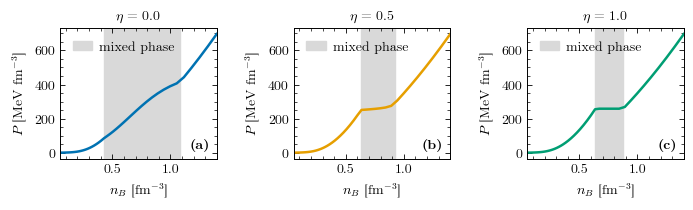

In [15]:
fig, axes = eta_grid()
for ax, eta in zip(axes, FIG_ETAS):
    table = figure_tables.get(eta)
    if table is None:
        ax.set_title(f"$\\eta$ = {eta:.1f} — did not solve")
        continue
    if table.has_transition:
        ax.axvspan(table.n_onset, table.n_offset, color="0.85", zorder=0,
                   label="mixed phase")
    ax.plot(table.n_B, table.P, color=ETA_COLOR[eta])
    ax.set_xlabel(r"$n_B$ [fm$^{-3}$]")
    ax.set_ylabel(r"$P$ [MeV fm$^{-3}$]")
    ax.set_xlim(FIG_N_B[0], FIG_N_B[-1])
    ax.set_title(f"$\\eta$ = {eta:.1f}")
    ax.legend(loc="upper left")
for ax, tag in zip(axes, "abcd"):
    panel_label(ax, f"({tag})", corner="lower right")
save_figure(fig, str(FIG_DIR / "pressure_window"))

### Family 2 — the quark volume fraction

`chi` is the fraction of volume the quark phase occupies, and it is the one
curve that says where the transition actually is: it leaves 0 at `n_onset` and
reaches 1 at `n_offset`. Outside the window the stitched table pins it at its
pure-phase value, so the curve is flat there by construction rather than by
accident.

Saved: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid/quark_fraction.{png, pdf}


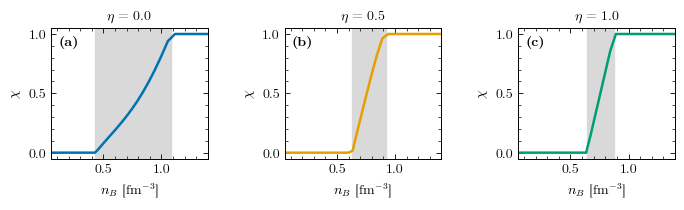

In [16]:
fig, axes = eta_grid()
for ax, eta in zip(axes, FIG_ETAS):
    table = figure_tables.get(eta)
    if table is None:
        ax.set_title(f"$\\eta$ = {eta:.1f} — did not solve")
        continue
    if table.has_transition:
        ax.axvspan(table.n_onset, table.n_offset, color="0.85", zorder=0)
    ax.plot(table.n_B, table.chi, color=ETA_COLOR[eta])
    ax.set_xlabel(r"$n_B$ [fm$^{-3}$]")
    ax.set_ylabel(r"$\chi$")
    ax.set_xlim(FIG_N_B[0], FIG_N_B[-1])
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"$\\eta$ = {eta:.1f}")
for ax, tag in zip(axes, "abcd"):
    panel_label(ax, f"({tag})", corner="upper left")
save_figure(fig, str(FIG_DIR / "quark_fraction"))

### Family 3 — the conserved charges, resolved by phase

One panel per conserved charge. The two solid curves are the hadronic and
quark shares on the volume-weighted convention; the dashed curve is their sum,
which is the global fraction the mode fixed and is therefore a check rather
than a result — section 6 measured it closing to 1e-15.

This is what `eta` controls and what a global sum cannot show. At `eta = 0`
the two phases share one electron sea, so neither is neutral on its own and
`Y_C_H` and `Y_C_Q` run apart; at `eta = 1` each neutralizes itself. The rows
come from `eos_table` rather than the stitched table, because the partition is
only defined inside the window.

In [17]:
CHARGE_PANELS = (("B", "Y_B_H", "Y_B_Q", None, r"$Y_B$"),
                 ("C", "Y_C_H", "Y_C_Q", "Y_C", r"$Y_C$"),
                 ("S", "Y_S_H", "Y_S_Q", "Y_S", r"$Y_S$"))

header("the charge-partition rows")
charge_rows = {}
for eta in FIG_ETAS:

    def build(eta=eta):
        return eos_table(PAIR, FIG_MODE, SPECIES,
                         {"nB": FIG_N_B, "T": np.array([FIG_T])},
                         eta=eta, window_only=True, verbose=False)

    status, result = run(f"eta={eta}", build)
    if status != "ok":
        continue
    rows, _ = result
    charge_rows[eta] = rows
    print(f"  [eta={eta:.2f}] {len(rows)} rows in the window")


=== the charge-partition rows ===


  [eta=0.00] 16 rows in the window


  [eta=0.50] 7 rows in the window


  [eta=1.00] 5 rows in the window


Saved: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid/charges_by_phase.{png, pdf}


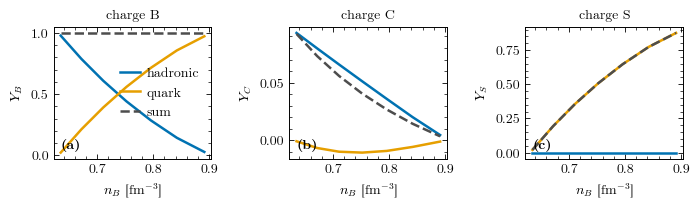

In [18]:
ETA_CHARGE = KNOBS.eta      # one construction; the panels are the charges here

fig, axes = paper_grid("1x3", mode="double", placeholder=False, aspect=1.2)
axes = axes[0]
rows = charge_rows.get(ETA_CHARGE, [])
for ax, (name, had_key, quark_key, total_key, label) in zip(axes, CHARGE_PANELS):
    if rows:
        n_B = np.array([r["n_B"] for r in rows])
        had = np.array([r[had_key] for r in rows])
        quark = np.array([r[quark_key] for r in rows])
        total = (had + quark if total_key is None
                 else np.array([r[total_key] for r in rows]))
        ax.plot(n_B, had, color=OKAB_CAT[0], label="hadronic")
        ax.plot(n_B, quark, color=OKAB_CAT[1], label="quark")
        ax.plot(n_B, total, color="0.3", ls="--", label="sum")
    ax.set_xlabel(r"$n_B$ [fm$^{-3}$]")
    ax.set_ylabel(label)
    ax.set_title(f"charge {name}")
axes[0].legend(loc="center right")
for ax, tag in zip(axes, "abcd"):
    panel_label(ax, f"({tag})", corner="lower left")
save_figure(fig, str(FIG_DIR / "charges_by_phase"))

### Family 4 — the transition curves

`n_onset` and `n_offset` against temperature, one pair per construction: the
phase diagram of the pairing in the plane the windows live in. Each point is
one line of one `eos_table` call, and the window it contributes is a returned
value, not something read back off the rows.

A line where the boundaries could not be located contributes no point rather
than a fabricated one, so a gap in a curve is the engine saying so.

In [19]:
header("the boundary curves")
boundaries = {}
for eta in FIG_ETAS:
    located = []
    for temperature in FIG_T_CURVE:

        def build(eta=eta, temperature=temperature):
            return eos_table(PAIR, FIG_MODE, SPECIES,
                             {"nB": FIG_N_B, "T": np.array([temperature])},
                             eta=eta, window_only=True, verbose=False)

        status, result = run(f"eta={eta} T={temperature}", build)
        if status != "ok":
            continue
        _, windows = result
        window = next(iter(windows.values()), None)
        if window is None or not np.isfinite(window.n_onset):
            print(f"  [eta={eta:.2f} T={temperature:4.1f}] no window located")
            continue
        located.append((temperature, window.n_onset, window.n_offset))
        print(f"  [eta={eta:.2f} T={temperature:4.1f}] "
              f"n_onset={window.n_onset:.4f}  n_offset={window.n_offset:.4f}")
    boundaries[eta] = np.array(located) if located else np.empty((0, 3))


=== the boundary curves ===


  [eta=0.00 T= 0.0] n_onset=0.4317  n_offset=1.0814


  [eta=0.00 T=10.0] n_onset=0.4270  n_offset=1.0715


  [eta=0.00 T=20.0] n_onset=0.4124  n_offset=1.0415


  [eta=0.00 T=30.0] n_onset=0.3873  n_offset=0.9908


...

  [eta=0.50 T=30.0] n_onset=0.5756  n_offset=0.8383


  [eta=1.00 T= 0.0] n_onset=0.6380  n_offset=0.8767


  [eta=1.00 T=10.0] n_onset=0.6323  n_offset=0.8673


  [eta=1.00 T=20.0] n_onset=0.6149  n_offset=0.8392


  [eta=1.00 T=30.0] n_onset=0.5849  n_offset=0.7920


Saved: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid/transition_curves.{png, pdf}


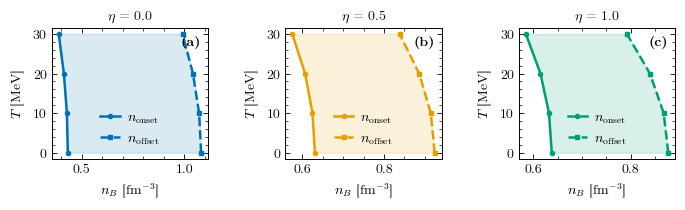

In [20]:
fig, axes = eta_grid()
for ax, eta in zip(axes, FIG_ETAS):
    found = boundaries.get(eta, np.empty((0, 3)))
    if found.size:
        ax.plot(found[:, 1], found[:, 0], color=ETA_COLOR[eta], marker="o",
                ms=3, label=r"$n_{\rm onset}$")
        ax.plot(found[:, 2], found[:, 0], color=ETA_COLOR[eta], marker="s",
                ms=3, ls="--", label=r"$n_{\rm offset}$")
        ax.fill_betweenx(found[:, 0], found[:, 1], found[:, 2],
                         color=ETA_COLOR[eta], alpha=0.15)
    ax.set_xlabel(r"$n_B$ [fm$^{-3}$]")
    ax.set_ylabel(r"$T$ [MeV]")
    ax.set_title(f"$\\eta$ = {eta:.1f}")
    ax.legend(loc="best")
for ax, tag in zip(axes, "abcd"):
    panel_label(ax, f"({tag})", corner="upper right")
save_figure(fig, str(FIG_DIR / "transition_curves"))

## 9. The TOV pass

`.to_tov()` is the declared contract into `eos.astro.tov`: an
`EOSTable_for_TOV`, which lives in `general/` — the layer the composite engine
and the structure solver may both import — and that object is the whole of the
handoff.

### The gate that runs before any integration

A table delivered to a structure solver has `P` non-decreasing in `n_B` and
`0 <= c_s^2 <= 1`. A raw branch may legitimately violate both inside a
first-order transition, where mechanical instability is real physics rather
than a bug — which is exactly the region this notebook is about, so the check
is not decoration here. It runs **before** the integration and returns a
status: a table that fails it is reported and left alone, never quietly
repaired and never turned into a mass that would mean nothing.

A Maxwell window is a genuine plateau, `dP = 0` exactly, so the monotonicity
is tested as "non-decreasing" against round-off rather than as strictly
rising — a strict test would reject the one construction that is most clearly
correct.

`c_s^2` here is the finite-difference `dP/deps` of the delivered table itself,
which is the quantity the solver will interpolate. It is not the model's
`eos_response`, which holds something fixed and answers a different question.

In [21]:
def deliverable(core):
    """The gate on a table about to be integrated.

    Returns `(ok, message, cs2)` with `cs2 = dP/deps` on the mid-points of the
    table. Nothing is modified: a failing table comes back as a status.
    """
    dP = np.diff(core.P)
    d_eps = np.diff(core.epsilon)
    cs2 = np.divide(dP, d_eps, out=np.full(dP.shape, np.nan), where=d_eps != 0)
    falling = np.flatnonzero(dP < 0.0)
    acausal = np.flatnonzero(~((cs2 >= 0.0) & (cs2 <= 1.0)))
    mid = 0.5 * (core.nB[:-1] + core.nB[1:])
    parts = []
    if falling.size:
        parts.append(f"P falls at {falling.size} of {dP.size} steps, first at "
                     f"n_B = {mid[falling[0]]:.3f} fm^-3")
    if acausal.size:
        parts.append(f"c_s^2 outside [0, 1] at {acausal.size} steps, first at "
                     f"n_B = {mid[acausal[0]]:.3f} fm^-3")
    ok = not parts
    message = ("P non-decreasing and 0 <= c_s^2 <= 1 over "
               f"{dP.size} steps, max c_s^2 = {np.nanmax(cs2):.3f}"
               if ok else "; ".join(parts))
    return ok, message, cs2


header("the gate, before integration")
cores = {}
for eta in FIG_ETAS:
    table = figure_tables.get(eta)
    if table is None:
        continue
    core = table.to_tov()
    ok, message, _ = deliverable(core)
    print(f"  [eta={eta:.2f}] {'PASS' if ok else 'HOLD'}  {message}")
    if ok:
        cores[eta] = core


=== the gate, before integration ===
  [eta=0.00] PASS  P non-decreasing and 0 <= c_s^2 <= 1 over 59 steps, max c_s^2 = 0.494
  [eta=0.50] PASS  P non-decreasing and 0 <= c_s^2 <= 1 over 59 steps, max c_s^2 = 0.636
  [eta=1.00] PASS  P non-decreasing and 0 <= c_s^2 <= 1 over 59 steps, max c_s^2 = 0.658


One sequence per construction, over the gated tables only, with the BPS crust
attached at `n_B = 0.08` fm^-3 — the density where that table tops out.
`compute_tov_sequence` returns `(e_c, n_c, P_c, R, M, M_b, k2, Lambda)` and
`find_mmax_precise` gives the index of the maximum-mass star, so the slice up
to it is the stable branch; everything past it is unstable and belongs on no
plane.

A construction whose table did not pass the gate has no entry here. That is
the point of the gate returning a status: the absence is visible, and no mass
stands in for it.

In [22]:
header("TOV sequences")
sequences = {}
for eta, core in cores.items():
    e_c = np.geomspace(250.0, 0.95 * float(core.epsilon.max()), FIG_N_STARS)
    sequence = compute_tov_sequence(core, e_c, add_crust_table="BPS",
                                    n_transition=0.08, verbose=False)
    index, _, m_max = find_mmax_precise(sequence)
    sequences[eta] = sequence[:index + 1]
    print(f"  [eta={eta:.2f}] M_max = {m_max:.3f} M_sun at "
          f"R = {sequence[index, 3]:5.2f} km, {len(sequences[eta]):2d} stable "
          f"of {len(sequence)} stars")


=== TOV sequences ===


  [eta=0.00] M_max = 2.249 M_sun at R = 12.38 km, 16 stable of 24 stars


  [eta=0.50] M_max = 2.339 M_sun at R = 12.64 km, 16 stable of 24 stars


  [eta=1.00] M_max = 2.343 M_sun at R = 12.64 km, 17 stable of 24 stars


### Mass–radius

The observational regions come from `eos.general.constraints.overlay` on the
`M-R` plane; nothing about them is drawn here.

Saved: /Users/mircoguerrini/Desktop/Research/Python_codes/eos/output/hybrid/mass_radius.{png, pdf}


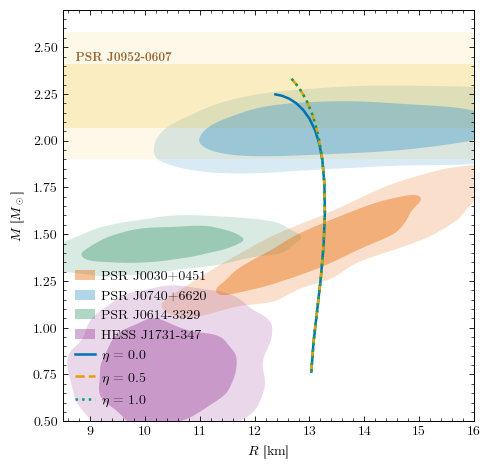

In [23]:
fig, axes = paper_grid("1x1", mode="centered", placeholder=False, aspect=1.0)
ax = axes[0][0]
overlay(ax, "M-R")
for eta in FIG_ETAS:
    sequence = sequences.get(eta)
    if sequence is None:
        continue
    ax.plot(sequence[:, 3], sequence[:, 4], color=ETA_COLOR[eta],
            ls=ETA_STYLE[eta], label=f"$\\eta$ = {eta:.1f}")
ax.set_xlabel(r"$R$ [km]")
ax.set_ylabel(r"$M$ [$M_\odot$]")
ax.set_xlim(8.5, 16.0)
ax.set_ylim(0.5, 2.7)
ax.legend(loc="lower left")
save_figure(fig, str(FIG_DIR / "mass_radius"))

## 10. Swapping both sides of the pair

The claim of section 4 was that a new pairing is a new adapter and never a new
engine. Section 4 tested it at one density; here both sides change at once and
the whole table is asked for — DID + NJL and DID + CCDM, neither of which
shares a model with the headline DD2 + vMIT.

A converged table is the floor, and depth is a runtime call: these get the
window and the row count, not the four figure families and not a TOV pass.
What is skipped is printed rather than quietly dropped.

In [24]:
SWAP_PAIRINGS = (("did", "njl"), ("did", "ccdm"))
SWAP_N_B = np.linspace(0.20, 1.40, 25)

header("both sides of the pair swapped")
print("  depth: a converged table and its windows. Skipped for runtime and "
      "NOT computed below —")
print("         the four figure families, the boundary curves in T, and the "
      "TOV pass.")

for had_name, quark_name in SWAP_PAIRINGS:

    def build(had_name=had_name, quark_name=quark_name):
        had_par = parameters_for(had_name, "default")
        quark_par = parameters_for(quark_name, "default")
        hadronic = getattr(adapters, f"{had_name}_phase")(
            had_par, hadronic_flags(had_name))
        quark = getattr(adapters, f"{quark_name}_phase")(quark_par)
        return eos_table((hadronic, quark), FIG_MODE, SPECIES,
                         {"nB": SWAP_N_B, "T": np.array([FIG_T])},
                         eta=KNOBS.eta, window_only=True, verbose=False)

    label = f"{had_name}+{quark_name}"
    status, result = run(label, build)
    if status != "ok":
        continue
    rows, windows = result
    for key, window in sorted(windows.items()):
        if window is None or not np.isfinite(window.n_onset):
            print(f"  [{label:10s}] line {key}: no window located on this grid")
            continue
        print(f"  [{label:10s}] line {key}: n_onset={window.n_onset:.4f}  "
              f"n_offset={window.n_offset:.4f} fm^-3")
    if rows:
        first, last = rows[0], rows[-1]
        print(f"  [{label:10s}] {len(rows)} rows   "
              f"P {first['P']:8.3f} -> {last['P']:8.3f}   "
              f"chi {first['chi']:+.4f} -> {last['chi']:+.4f}")
    else:
        print(f"  [{label:10s}] no in-window rows on this grid")


=== both sides of the pair swapped ===
  depth: a converged table and its windows. Skipped for runtime and NOT computed below —
         the four figure families, the boundary curves in T, and the TOV pass.


  [did+njl   ] line (0.0,): n_onset=1.1818  n_offset=1.2875 fm^-3
  [did+njl   ] 2 rows   P  246.566 ->  250.580   chi +0.9093 -> +0.9722


  [did+ccdm  ] line (0.0,): n_onset=0.7810  n_offset=1.4000 fm^-3
  [did+ccdm  ] 13 rows   P  362.233 ->  363.846   chi +0.0139 -> +0.4535


## 11. Against the retired DD2 + vMIT tables

`eos_tables_DD2vMIT/` at the repository root holds the tables and figures of
the first-generation hybrid notebook, and each of its CSV files carries the
run's full provenance in a `# key = value` header — every coupling of the
hadronic parametrisation, the vMIT bag constant and quark masses, and every
species flag. That is enough to rebuild the exact inputs and ask the present
engine for the same numbers.

It is the cheapest end-to-end check there is that a refactor preserved the
physics, and it is a numeric one rather than an eyeball: the boundaries of a
first-order transition are the most sensitive thing the engine computes, so
two of them agreeing is a strong statement about everything upstream.

The parametrisation in that header is a custom set, not one of the published
ones — `gamma_sigma` and `n_sat` differ from `DD2Y`'s in the fourth digit, and
`B4` is 170 rather than the shipped default of 180 — which is precisely why
it is read out of the file instead of guessed at.

In [25]:
import ast
import dataclasses

RETIRED = ROOT / "eos_tables_DD2vMIT"
RETIRED_FILE = RETIRED / "mixed_beta_eq_neutrinoless_eta0.00.csv"

# n_onset, n_offset at T = 0 in beta equilibrium, read from completeness.csv
# of that run, one entry per eta it was built at.
RETIRED_WINDOWS = {0.0: (0.331028523, 1.07830952),
                   0.3: (0.876716755, 0.997672412),
                   1.0: (0.883484512, 0.966425534)}


def provenance(path):
    """The `# key = value` block the retired notebook wrote above its columns.

    The array-valued entries wrap onto continuation lines that carry no `#`,
    so the block is read to the first line that begins with neither.
    """
    entries = {}
    for line in Path(path).read_text().splitlines():
        if not (line.startswith("#") or line.startswith(" ")):
            break
        if line.startswith("# ") and " = " in line:
            key, _, value = line[2:].partition(" = ")
            entries[key] = value
    return entries


if RETIRED_FILE.exists():
    from eos.dd2 import Parameters as DD2Parameters
    from eos.dd2 import SpeciesFlags as DD2Flags
    from eos.vmit import Parameters as VMITParameters

    entries = provenance(RETIRED_FILE)
    fields = {f.name for f in dataclasses.fields(DD2Parameters)}
    retired_par = DD2Parameters(**{
        name: (value if name == "nucleon_mass_mode" else ast.literal_eval(value))
        for key, value in entries.items()
        if key.startswith("parametrization.")
        and (name := key.split(".", 1)[1]) in fields})
    retired_quark = VMITParameters(
        name="vMIT_from_header",
        m_u=float(entries["vmit.m_u"]), m_d=float(entries["vmit.m_d"]),
        m_s=float(entries["vmit.m_s"]), a=float(entries["vmit.a"]),
        B4=float(entries["vmit.B4"]))
    # The retired flag names for the meson sectors are this repository's
    # `thermal_mesons` and `thermal_vectors`; the rest carry over unchanged.
    retired_flags = DD2Flags(
        hyperons=entries["flags.hyperons"] == "True",
        deltas=entries["flags.deltas"] == "True",
        muons=entries["flags.muons"] == "True",
        thermal_mesons=entries["flags.include_pseudoscalars"] == "True",
        thermal_vectors=entries["flags.include_thermal_vectors"] == "True",
        thermal_neutrinos=False,
        photons=entries["flags.photons"] == "True",
        neutrinos=entries["flags.neutrinos"] == "True",
        phi_field=entries["flags.phi_field"] == "True",
        sigma_star=entries["flags.sigma_star"] == "True")
    retired_pair = (adapters.dd2_phase(retired_par, retired_flags),
                    adapters.vmit_phase(retired_quark))
    print(f"rebuilt from {RETIRED_FILE.name}:")
    print(f"  gamma_sigma = {retired_par.gamma_sigma}  "
          f"n_sat = {retired_par.n_sat}  B4 = {retired_quark.B4}")
    print(f"  hyperons={retired_flags.hyperons} deltas={retired_flags.deltas} "
          f"muons={retired_flags.muons} "
          f"thermal_mesons={retired_flags.thermal_mesons}")
else:
    retired_pair = None
    print(f"{RETIRED} not present in this checkout; the comparison is skipped.")

rebuilt from mixed_beta_eq_neutrinoless_eta0.00.csv:
  gamma_sigma = 10.686850458775691  n_sat = 0.149077  B4 = 170.0
  hyperons=True deltas=True muons=True thermal_mesons=True


The comparison itself. Only the boundaries are compared: they are the number
the retired run recorded per line in its `completeness.csv`, and they are the
number a change anywhere in the hadronic sector, the quark sector or the
coupling between them would move.

In [26]:
if retired_pair is not None:
    header("boundaries, now against the retired run")
    print("             now                    retired               difference")
    for eta, (was_onset, was_offset) in RETIRED_WINDOWS.items():

        def build(eta=eta):
            return eos_table(retired_pair, "beta_eq_neutrinoless", SPECIES,
                             {"nB": FIG_N_B, "T": np.array([0.0])},
                             eta=eta, window_only=True, verbose=False)

        status, result = run(f"eta={eta}", build)
        if status != "ok":
            continue
        _, windows = result
        window = next(iter(windows.values()), None)
        if window is None or not np.isfinite(window.n_onset):
            print(f"  [eta={eta:.2f}] no window located")
            continue
        d_on = 100.0 * abs(window.n_onset - was_onset) / was_onset
        d_off = 100.0 * abs(window.n_offset - was_offset) / was_offset
        print(f"  [eta={eta:.2f}] {window.n_onset:.6f} {window.n_offset:.6f}"
              f"    {was_onset:.6f} {was_offset:.6f}"
              f"    {d_on:.2f}% {d_off:.2f}%")


=== boundaries, now against the retired run ===
             now                    retired               difference


  [eta=0.00] 0.332477 1.078811    0.331029 1.078310    0.44% 0.05%


  [eta=0.30] 0.878653 0.993398    0.876717 0.997672    0.22% 0.43%


  [eta=1.00] 0.885372 0.964581    0.883485 0.966426    0.21% 0.19%


## Two boundaries this notebook does not cross

**ENJL is not here.** `enjl_branch_pair` is an `eos/mixed` adapter, but it
pairs two branches of one functional rather than two models, and the physics
that makes it interesting is ENJL's own — so it belongs to `enjl_eos`, not to
this one.

**The sound speed is the delivered table's, not the model's.** Section 9's
gate differentiates the table it is about to hand over, which is the quantity
the structure solver interpolates. The response functions a model computes at
fixed composition or fixed entropy are a different question and are asked in
the notebooks of the models themselves.